# Image Processing 

### You are a computer vision engineer at FreshTrack, a produce supply chain company. Warehouses receive mixed crates of fruit and need to automatically sort them by type, flag color defects (underripe or overripe), and count individual pieces before packing. Manualinspection is slow and inconsistent under variable warehouse lighting Your job is to build a CV pipeline using OpenCV that can: (1) identify fruit types by color, (2) clean up noisy camera images, (3) detect fruit shape features, and (4) count individual round fruits in a batch image.

In [30]:
import cv2 as cv
import matplotlib.pyplot as plt 
import numpy as np 

# Part A — Color Space & Fruit Segmentation


### 1. Load red_apple.jpg in BGR using cv2.imread(). Display it correctly in Matplotlib (convert to RGB first). Then display the raw BGR version. What do you notice about the colors?

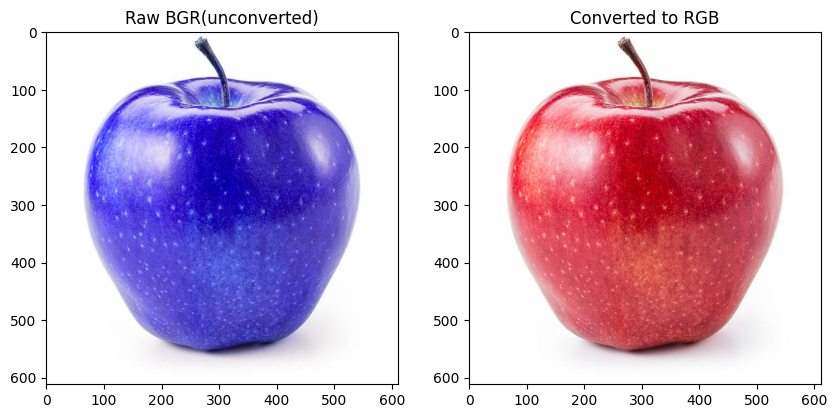

In [2]:
img_bgr = cv.imread("Images/red_apple.png")
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)



fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(img_bgr)
axes[0].set_title('Raw BGR(unconverted)')
axes[1].imshow(img_rgb)
axes[1].set_title('Converted to RGB')
plt.show()



> Note

A digital color img is a 3D grid of number height x widht x 2(BGR).
Open CV stores them as BGR not RGB

plt, PIL, and everyother thing expects RBG format

In [3]:
# observations 
# the apple is blue in left side and red in right side the 
# the correct order of the image was RGB; the left one switched 
# the value of R(Red) with the blue 
# left image - 0000FF
# right image - FF0000


### 2. Convert red_apple.jpg to HSV. Visualize the H,S, and V channels side by side as grayscale images. Which channel best separates the fruit from its white background?

Text(0.5, 1.0, 'HSV')

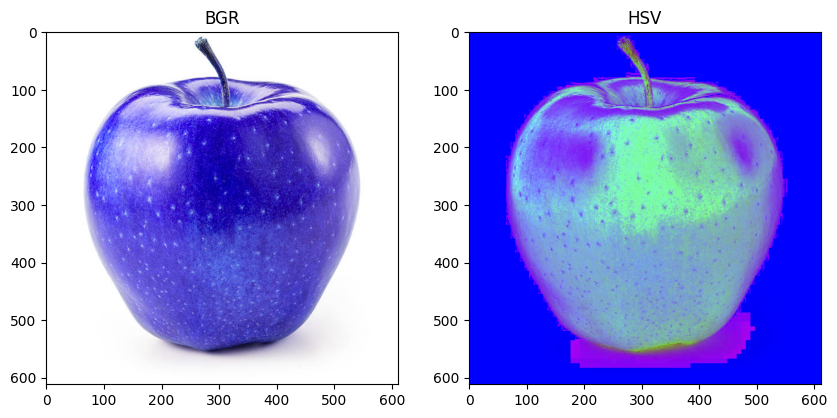

In [4]:
img_bgr = cv.imread("Images/red_apple.png")
img_hsv = cv.cvtColor(img_rgb, cv.COLOR_BGR2HSV)

fig, axes = plt.subplots(1,2, figsize = (10,5))
axes[0].imshow(img_bgr)
axes[0].set_title("BGR")
axes[1].imshow(img_hsv)
axes[1].set_title('HSV')


# HSV = HUe, Saturation, Value

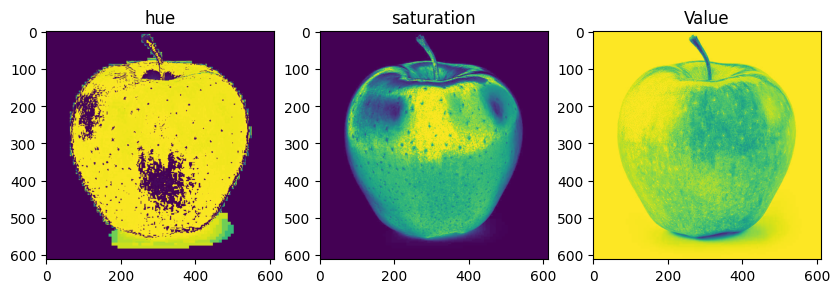

In [5]:
img_hsv = cv.cvtColor(img_rgb, cv.COLOR_RGB2HSV)

h, s, v = cv.split(img_hsv)

fig, axes = plt.subplots(1,3, figsize = (10,5))
axes[0].imshow(h)
axes[0].set_title("hue")
axes[1].imshow(s)
axes[1].set_title("saturation")
axes[2].imshow(v)
axes[2].set_title("Value")
plt.show()


The saturation (S) channel seprates the fruit from its white background. Whie is defined as a color with essentially zero saturation, regardless of how bright it is, white carries no "colourfullness

### 3. Masking by color: use cv2.inRange() in HSV to isolate the red apple. Red wraps around the Hue axis (0–10 and 170–180). Create two masks and combine with cv2.bitwise_or(). Display: original | mask | masked result.

Text(0.5, 1.0, 'mask result ')

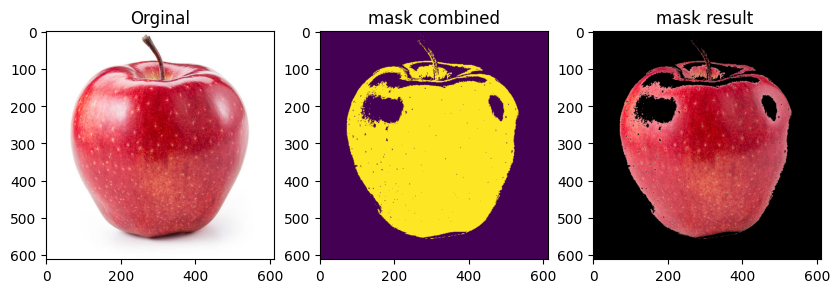

In [6]:
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 100, 100])
upper_red2 = np.array([179, 255,255])
mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)
mask_combined = cv.bitwise_or(mask1, mask2)
mask_result = cv.bitwise_and(img_rgb, img_rgb, mask=mask_combined)

fig, axes = plt.subplots(1,3, figsize= (10,5))
axes[0].imshow(img_rgb)
axes[0].set_title('Orginal')
axes[1].imshow(mask_combined)
axes[1].set_title('mask combined')
axes[2].imshow(mask_result)
axes[2].set_title('mask result ')



### 4.Color table task: repeat the HSV masking for green_apple.jpg, banana.jpg, and lime.jpg. Record each fruit’s working HSV range as a markdown table: Fruit | H_min | H_max | S_min | S_max | V_min |  V_max.

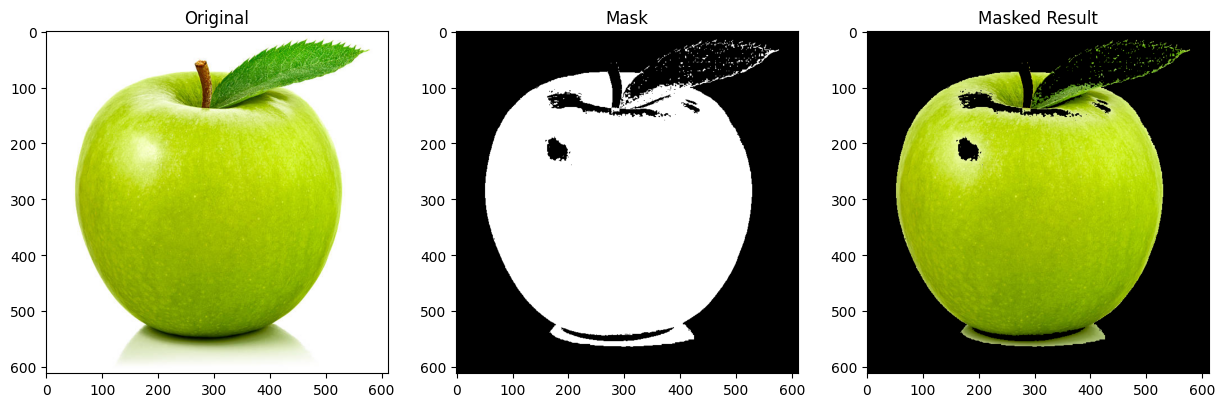

In [7]:
img_green = cv.imread('Images/green_apple.png')
img_green_hsv = cv.cvtColor(img_green, cv.COLOR_BGR2HSV)
img_green_rgb = cv.cvtColor(img_green, cv.COLOR_BGR2RGB)

lower_green = np.array([25, 90, 80])
upper_green = np.array([45, 255, 255])

mask_green = cv.inRange(img_green_hsv, lower_green, upper_green)
result_green = cv.bitwise_and(img_green_rgb, img_green_rgb, mask=mask_green)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_green_rgb); axes[0].set_title('Original')
axes[1].imshow(mask_green, cmap='gray'); axes[1].set_title('Mask')
axes[2].imshow(result_green); axes[2].set_title('Masked Result')
plt.show()

In [8]:
print(img_green_hsv[100, 100])
print(img_green_hsv[150, 150])
print(img_green_hsv[150, 150])
print(img_green_hsv[130, 160])
print(img_green_hsv[170, 140])

[  0   0 255]
[ 35 171 232]
[ 35 171 232]
[ 35 120 229]
[ 35 232 225]


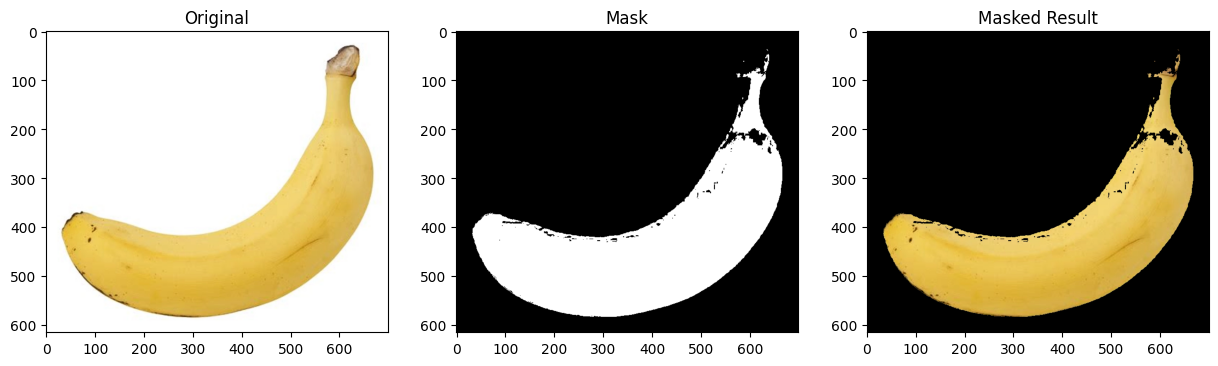

In [9]:
img_banana = cv.imread('Images/banana.png')
img_banana_hsv = cv.cvtColor(img_banana, cv.COLOR_BGR2HSV)
img_banana_rgb = cv.cvtColor(img_banana, cv.COLOR_BGR2RGB)

lower_banana = np.array([14, 130, 90])
upper_banana = np.array([31, 255, 255])

mask_banana = cv.inRange(img_banana_hsv, lower_banana, upper_banana)
result_banana = cv.bitwise_and(img_banana_rgb, img_banana_rgb, mask=mask_banana)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_banana_rgb); axes[0].set_title('Original')
axes[1].imshow(mask_banana, cmap='gray'); axes[1].set_title('Mask')
axes[2].imshow(result_banana); axes[2].set_title('Masked Result')
plt.show()

In [10]:
img_lime = cv.imread('Images/lime.png')
img_lime_hsv = cv.cvtColor(img_lime, cv.COLOR_BGR2HSV)
img_lime_rgb = cv.cvtColor(img_lime, cv.COLOR_BGR2RGB)


print(img_lime_hsv[200, 300])   
print(img_lime_hsv[150, 250])   
print(img_lime_hsv[220, 350])   
print(img_lime_hsv[110, 300])   

[ 34 104 225]
[ 36 157 233]
[ 36 169 216]
[  0   0 254]


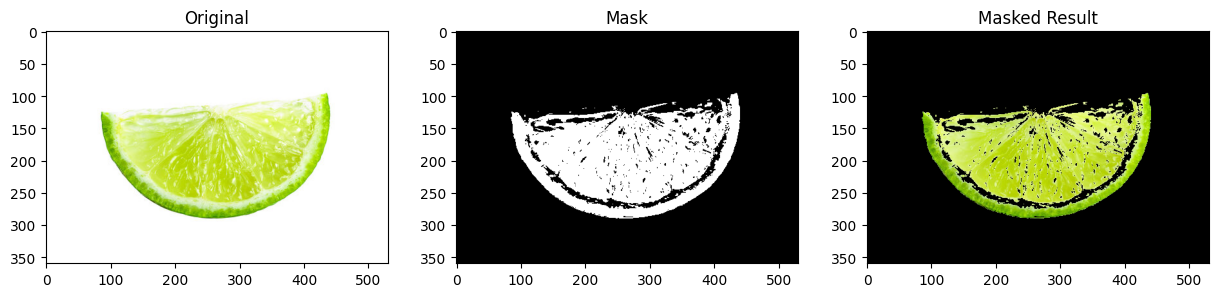

In [11]:

lower_lime = np.array([24, 80, 90])
upper_lime = np.array([46, 255, 255])

mask_lime = cv.inRange(img_lime_hsv, lower_lime, upper_lime)
result_lime = cv.bitwise_and(img_lime_rgb, img_lime_rgb, mask=mask_lime)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_lime_rgb); axes[0].set_title('Original')
axes[1].imshow(mask_lime, cmap='gray'); axes[1].set_title('Mask')
axes[2].imshow(result_lime); axes[2].set_title('Masked Result')
plt.show()

### Fruit HSV Color Ranges 

| Fruit | H_min | H_max | S_min | S_max | V_min | V_max |
|---|---|---|---|---|---|---|
| Green Apple | 25 | 45 | 90 | 255 | 80 | 255 |
| Banana | 14 | 31 | 130 | 255 | 90 | 255 |
| Lime | 24 | 46 | 80 | 255 | 90 | 255 |

### 5.Apply manual brightness/contrast to a dark banana image(alpha=1.3, beta=20) using NumPy. Clip to [0,255] and convert to uint8. Compareto cv2.convertScaleAbs(). Does it make the HSV mask more reliable?

`new pixel = alpha x old_pixel + beta`
- alpha (contrast/gain) :multiplies every pixel value. alpha > 1 stretches the spread between dark and light pixels apart (more contrast). alpha=1.3 means every pixel gets 30% "stronger."

- beta (brightness/offset) :adds a flat amount to every pixel. beta=20 just shifts the whole image 20 units brighter, uniformly.

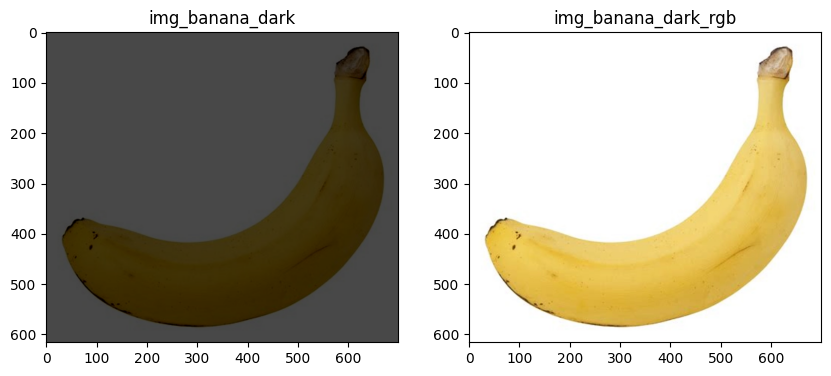

In [12]:
img_banana = cv.imread('Images/banana.png')
img_banana_rgb = cv.cvtColor(img_banana, cv.COLOR_BGR2RGB)

# darken it artificially
img_banana_dark = np.clip(img_banana_rgb.astype(np.float32) * 0.4 - 30, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(img_banana_dark)
axes[0].set_title('img_banana_dark')
axes[1].imshow(img_banana_rgb)
plt.title('img_banana_dark_rgb')
plt.show()

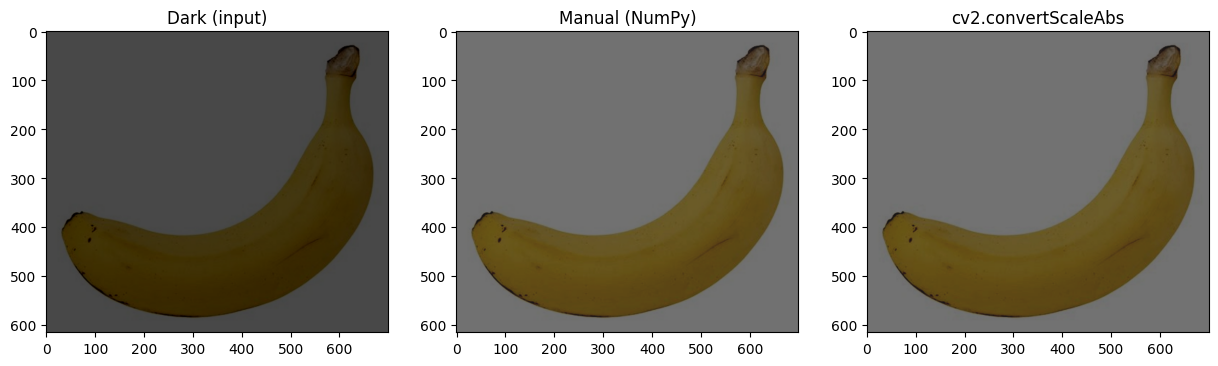

Max pixel difference: 1
Are they identical?: False


In [13]:
alpha = 1.3
beta = 20

# Manual method
manual = img_banana_dark.astype(np.float32) * alpha + beta
manual_clipped = np.clip(manual, 0, 255).astype(np.uint8)

opencv_version = cv.convertScaleAbs(img_banana_dark, alpha=alpha, beta=beta)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_banana_dark); axes[0].set_title('Dark (input)')
axes[1].imshow(manual_clipped); axes[1].set_title('Manual (NumPy)')
axes[2].imshow(opencv_version); axes[2].set_title('cv2.convertScaleAbs')
plt.show()

# Are they actually identical?
diff = cv.absdiff(manual_clipped, opencv_version)
print("Max pixel difference:", diff.max())
print("Are they identical?:", np.array_equal(manual_clipped, opencv_version))

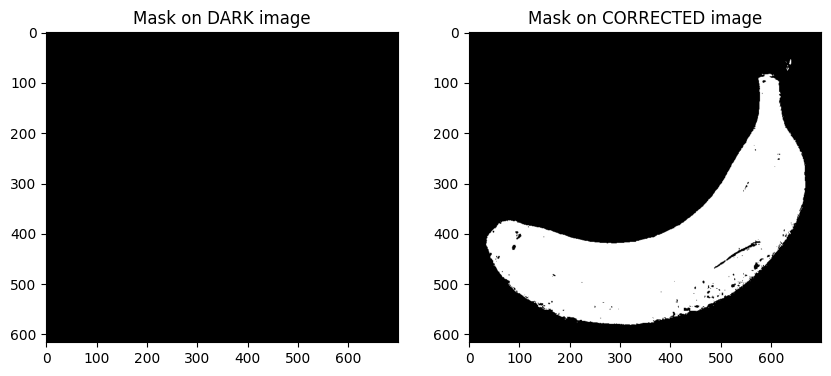

In [14]:
# HSV mask on the DARK banana (before correction)
dark_hsv = cv.cvtColor(img_banana_dark, cv.COLOR_RGB2HSV)
mask_dark = cv.inRange(dark_hsv, lower_banana, upper_banana)

# HSV mask on the CORRECTED banana (after alpha/beta fix)
corrected_hsv = cv.cvtColor(manual_clipped, cv.COLOR_RGB2HSV)
mask_corrected = cv.inRange(corrected_hsv, lower_banana, upper_banana)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mask_dark, cmap='gray')
axes[0].set_title('Mask on DARK image')
axes[1].imshow(mask_corrected, cmap='gray')
axes[1].set_title('Mask on CORRECTED image')
plt.show()

#### Does it make the HSV mask more reliable?
Yes, decisively. The dark image is 0% detected (mask completely fails), while brightness/contrast correction restores it to a fully working, near-original-quality mask. Correction doesn't just "help a little" — it's the difference between total failure and success here.

### 6.  Reflection: why does HSV work better than RGB for fruit color segmentation? When would it fail? (Hint: try a very dark purple grape or blueberry.)

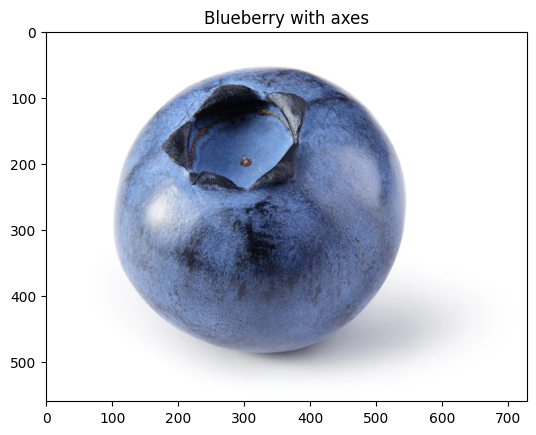

In [15]:
img_blueberry = cv.imread('Images/blueberry.png')   # adjust filename/extension to match your file
img_blueberry_hsv = cv.cvtColor(img_blueberry, cv.COLOR_BGR2HSV)
img_blueberry_rgb = cv.cvtColor(img_blueberry, cv.COLOR_BGR2RGB)

plt.imshow(img_blueberry_rgb)
plt.title('Blueberry with axes')
plt.show()

In [16]:
print("Highlight:", img_blueberry_hsv[180, 180])
print("Mid-tone", img_blueberry_hsv[280, 350])
print("Shadow:", img_blueberry_hsv[350, 450])
print("Near-black:", img_blueberry_hsv[150, 300])

Highlight: [125  46 112]
Mid-tone [112 115 146]
Shadow: [110 106 166]
Near-black: [110 158 108]


HSV works better than RGB for fruit segmentation because it seprates color identity(Hue) from lighting(Value), So a red apple stays roughly the same hue whether it's in sun or shadow, while in RGB the same apple's numbers shifted entireely with brightness. IT failes in two cases 

1. when two fruits share a similar hue, like our lime(h 24-46) and green apple(H 25-45), which overlap alomost completly and ca't be separated by color alone 

2. at a very low brightness(dark purple grapes, blueberries), wher HUe itself becomes unstable and noisy, since it's mathematically derived from ratio between RGB that breaks down near black  

# Part B — Histograms & Filtering

### 1. Load strawberry.jpg as grayscale. Plot its histogram. Is the image well-exposed? What does the histogram shape tell you about contrast?

In [17]:
# this collapses the 3 color channels into 1 brightness channedl 
# using weighted averages of RGB 
img_strawberry_gray= cv.imread("Images/strawberry.png", cv.IMREAD_GRAYSCALE)

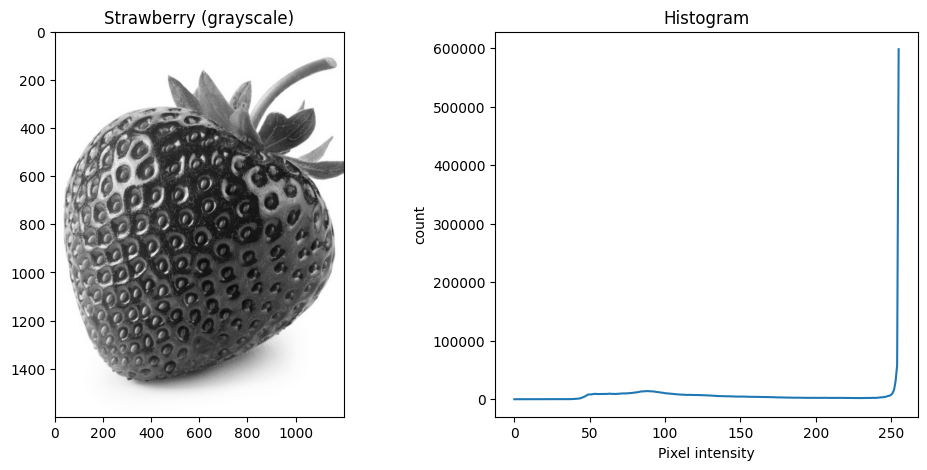

In [18]:
hist = cv.calcHist([img_strawberry_gray], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize = (12,5))
axes[0].imshow(img_strawberry_gray, cmap='gray')
axes[0].set_title("Strawberry (grayscale)")
axes[1].plot(hist)
axes[1].set_title("Histogram")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("count")
plt.show()


That giant Spike at 255 is almost certainly the white background contributes a huge flat block of identical bright pixels,the small bump around 50-100 is the actual strawberry itself, it seeds, ,shadows and red pat 

### 2.Apply global histogram equalization (cv2.equalizeHist()). Then apply CLAHE with clipLimit=2.0 and clipLimit=8.0. Show all four versions side by side (original, equalized, CLAHE-2, CLAHE-8). Which helps the HSV segmentation mask most?

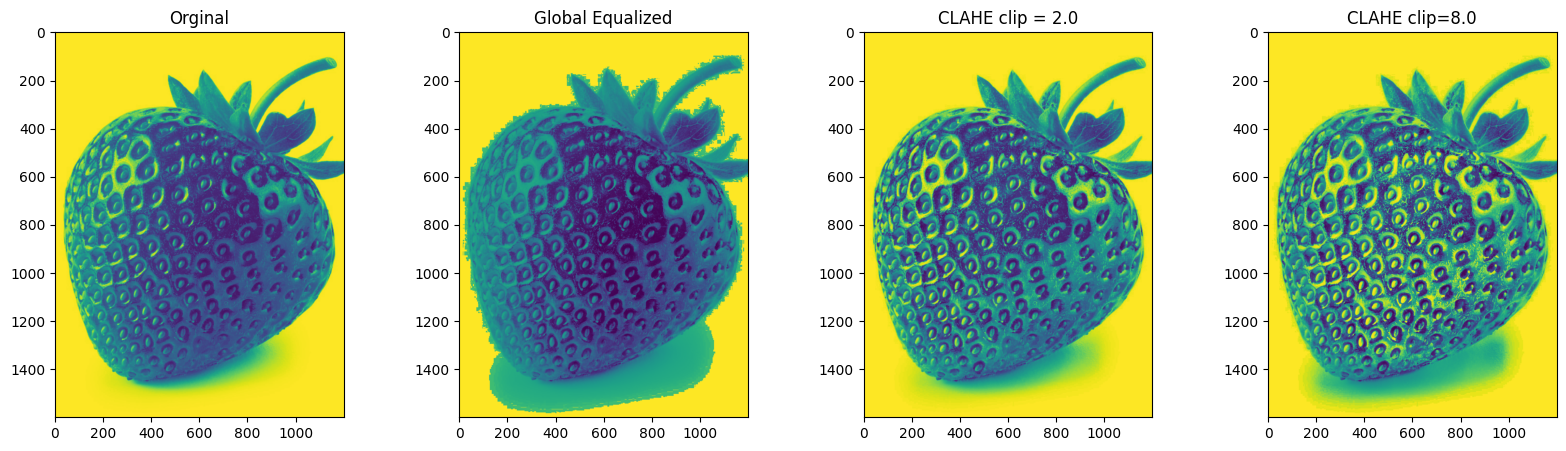

In [19]:
eq = cv.equalizeHist(img_strawberry_gray)

# CHALE clipLimit = 2.0
clahe2 = cv.createCLAHE(clipLimit=2.0, tileGridSize= (8,8))
clahe2_img = clahe2.apply(img_strawberry_gray)

# CHALE clipLimit = 8.0
clahe8 = cv.createCLAHE(clipLimit=8.0, tileGridSize = (8,8))
clahe8_img = clahe8.apply(img_strawberry_gray)

fig, axes = plt.subplots(1, 4, figsize = (20,5))
axes[0].imshow(img_strawberry_gray)
axes[0].set_title("Orginal")
axes[1].imshow(eq)
axes[1].set_title("Global Equalized")
axes[2].imshow(clahe2_img)
axes[2].set_title('CLAHE clip = 2.0')
axes[3].imshow(clahe8_img)
axes[3].set_title('CLAHE clip=8.0')
plt.show()

In [20]:
# Which helps the HSV segmentation mask most?
# CLAHE with clipLimit=2.0 helps the HSV segmentation mask most

### 3.Noise experiment: add Gaussian noise (mean=0, std=25) to orange.jpg using np.random.normal(). Apply Gaussian blur, median filter, and bilateral filter. Which removes the noise best while keeping the fruit’s edge sharp? Plot all four for comparison.

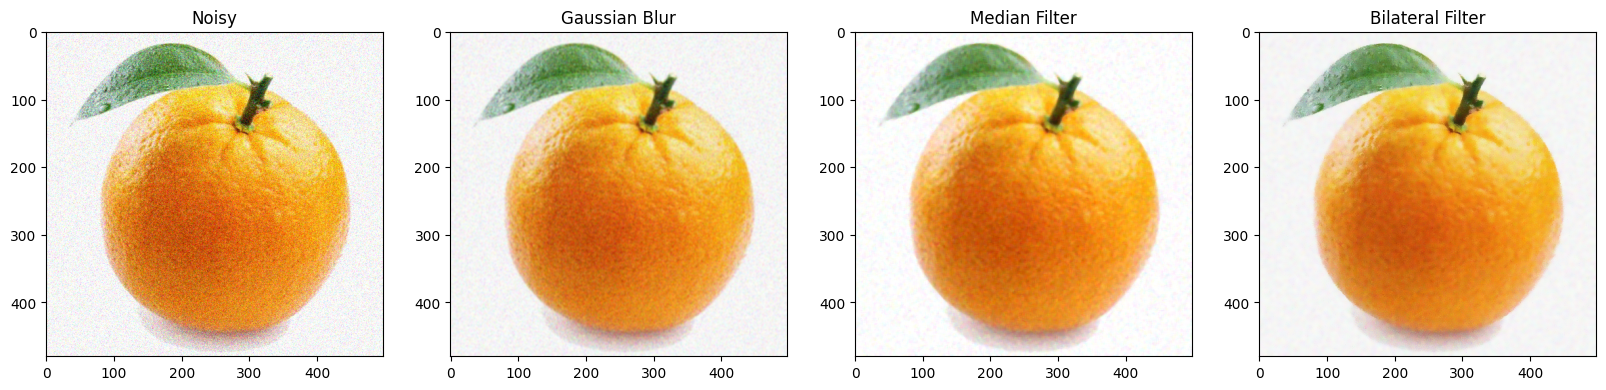

In [35]:
img_orange = cv.imread('Images/orange.png')
img_orange_rgb = cv.cvtColor(img_orange, cv.COLOR_BGR2RGB)

#  add Gaussian noise
noise = np.random.normal(0, 25, img_orange_rgb.shape)
noisy = np.clip(img_orange_rgb.astype(np.float32) + noise, 0, 255).astype(np.uint8)

#  apply the three filters
gaussian_blur = cv.GaussianBlur(noisy, (5, 5), 0)
median_blur = cv.medianBlur(noisy, 5)
bilateral = cv.bilateralFilter(noisy, 9, 75, 75)

#  plot all four
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(noisy)
axes[0].set_title('Noisy')
axes[1].imshow(gaussian_blur)
axes[1].set_title('Gaussian Blur')
axes[2].imshow(median_blur)
axes[2].set_title('Median Filter')
axes[3].imshow(bilateral)
axes[3].set_title('Bilateral Filter')
plt.show()

### 4.  Extended — manual convolution: implement conv2d() from scratch. Apply a Sobel X kernel to the grayscale banana image. Compare to cv2.filter2D(). What is the mean absolute difference? Explain any discrepancy.

Mean Absolute Difference: 2.9119203


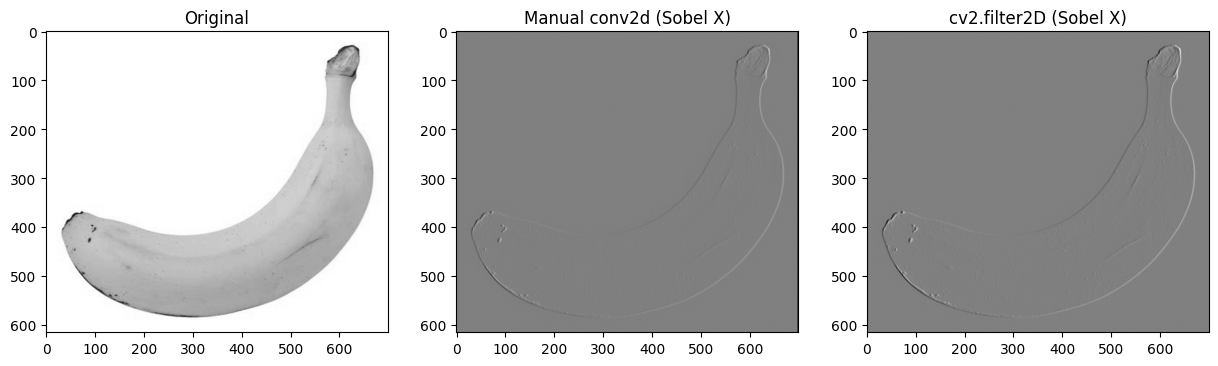

In [36]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# Load grayscale banana
img_banana_gray = cv.imread('Images/banana.png', cv.IMREAD_GRAYSCALE)

# manual conv2d
def conv2d(image, kernel):
    img = image.astype(np.float32)
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    # pad image so output size == input size
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    output = np.zeros_like(img)
    rows, cols = img.shape

    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+kh, j:j+kw]          # grab the neighborhood
            output[i, j] = np.sum(region * kernel)    # multiply-and-sum

    return output

# sobel X kernel
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Apply  conv2d
manual_result = conv2d(img_banana_gray, sobel_x)

cv2_result = cv.filter2D(img_banana_gray.astype(np.float32), -1, sobel_x)

# Compare
mad = np.mean(np.abs(manual_result - cv2_result))
print("Mean Absolute Difference:", mad)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_banana_gray, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(manual_result, cmap='gray')
axes[1].set_title('Manual conv2d (Sobel X)')
axes[2].imshow(cv2_result, cmap='gray')
axes[2].set_title('cv2.filter2D (Sobel X)')
plt.show()

Mean Absolute Difference = 2.9119203. The discrepancy cmes from border handling, my namual conv2d pads edges with zeros, while `cv2.filter2d`  mirrors nearby pixels `BORDER_REFLECT_101`  by default. THe two methods agree everywhere in tehinterior; they only differ in a thin 1-pixel strip around the borderm which gets averaged down to a samall overall Mean Absolute Difference 

# Part C — Morphology & Mask Cleanup
A raw HSV color mask is rarely
clean — it has small noise blobs from reflections and gaps from shadows.
Morphological operations fix this before any shape analysis.

### 5.Take your banana HSV mask from Part A. Apply erosion with a 5×5 kernel. What happens to the mask?

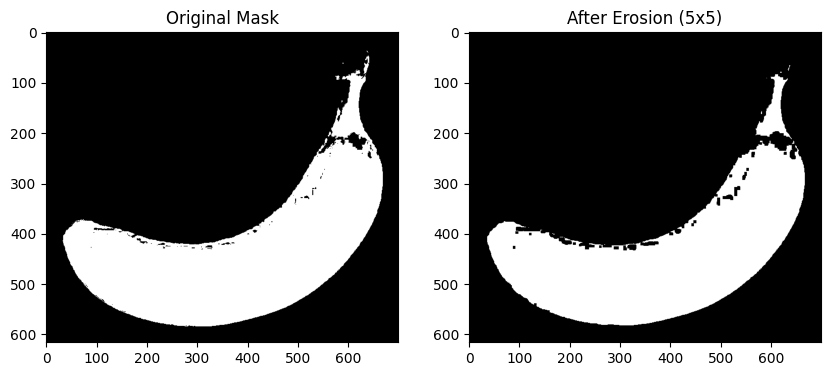

In [37]:
kernel = np.ones((5,5), np.uint8)
eroded = cv.erode(mask_banana, kernel, iterations=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mask_banana, cmap='gray')
axes[0].set_title('Original Mask')
axes[1].imshow(eroded, cmap='gray')
axes[1].set_title('After Erosion (5x5)')
plt.show()

Comparing the two panels closely:

The overall banana silhouette looks nearly identical in outline, hard to see much shrinkage at this zoom level (with only 1 erosion iteration and a large ~700px image, 2px of edge-thinning is subtle).
Look specifically at the stem tip area (top-right) and the blemish specks along the bottom edge in the eroded version, those small dark speckle patches look slightly more connected/cleaner, since erosion is chipping away at small white fragments near those noisy edge

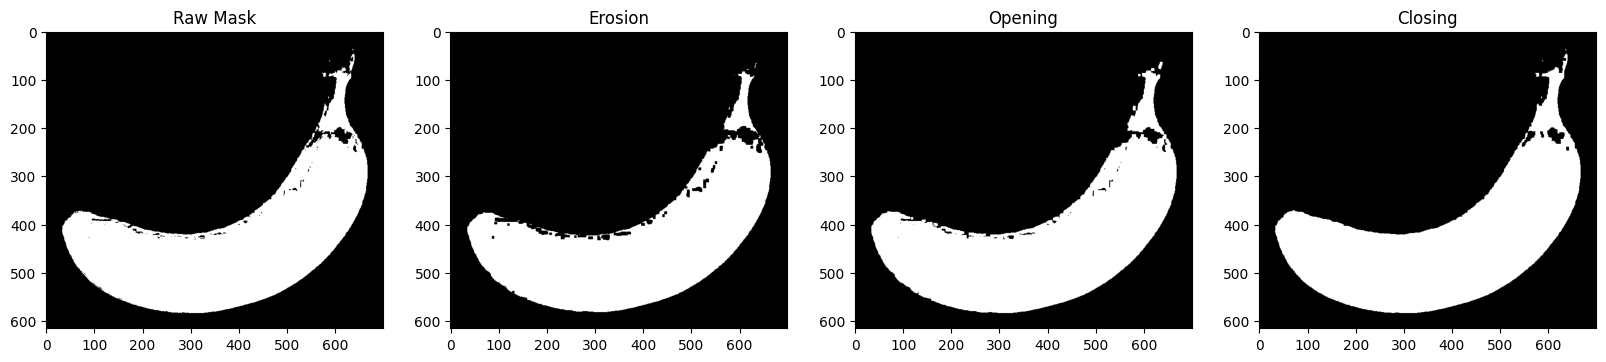

In [38]:
kernel = np.ones((5,5), np.uint8)

eroded = cv.erode(mask_banana, kernel, iterations=1)
opened = cv.morphologyEx(mask_banana, cv.MORPH_OPEN, kernel)
closed = cv.morphologyEx(mask_banana, cv.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(mask_banana, cmap='gray'); axes[0].set_title('Raw Mask')
axes[1].imshow(eroded, cmap='gray')
axes[1].set_title('Erosion')
axes[2].imshow(opened, cmap='gray')
axes[2].set_title('Opening')
axes[3].imshow(closed, cmap='gray')
axes[3].set_title('Closing')
plt.show()

### 7. Apply the morphological gradient (dilation − erosion)to extract just the outline of the banana. Overlay it on the original image ingreen.

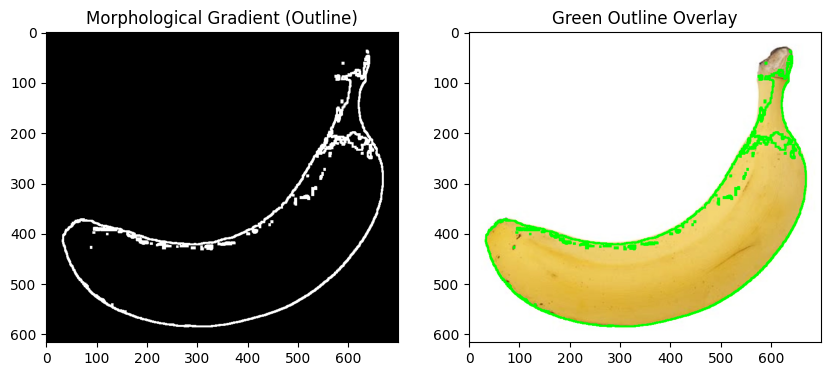

In [39]:
kernel = np.ones((5,5), np.uint8)

dilated = cv.dilate(mask_banana, kernel, iterations=1)
eroded = cv.erode(mask_banana, kernel, iterations=1)
gradient = cv.subtract(dilated, eroded)  
# Overlay in green
overlay = img_banana_rgb.copy()
overlay[gradient == 255] = [0, 255, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gradient, cmap='gray')
axes[0].set_title('Morphological Gradient (Outline)')
axes[1].imshow(overlay)
axes[1].set_title('Green Outline Overlay')
plt.show()

### 8. Reflection: what would happen if you applied morphological operations directly to the BGR fruit image instead of the binary mask? Try it and describe what you see.

Erosion/dilation generalize to color images by operating per-channel, using min (erosion) or max (dilation) within the neighborhood  instead of the binary "all must be white" / "any is white" rule. Erosion darkens the image (pulls every pixel toward its darkest nearby neighbor across R,G,B independently); dilation brightens it. Since each channel is processed separately, colors can shift into combinations that didn't exist in the original image  it becomes a strange non-standard blur, not meaningful "shape cleanup."

### 9. Demo with j.png: apply erosion, dilation, opening, closing, Top Hat, and Black Hat. Show all six results. Which operation isolates the thin strokes?

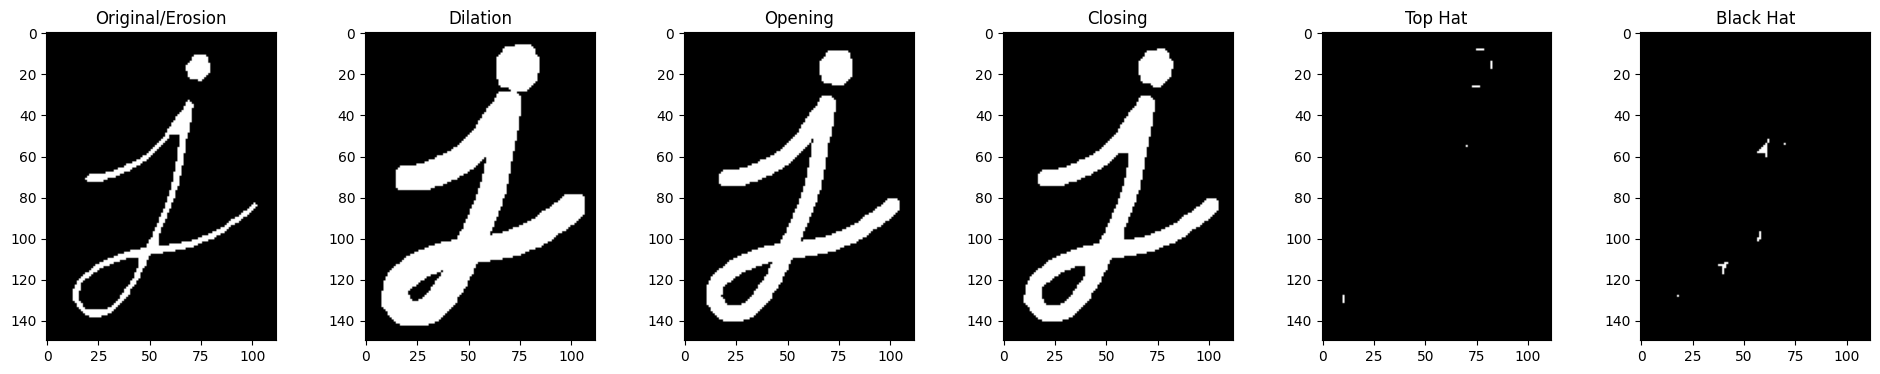

In [41]:
img_morph = cv.imread('Images/morphology.png', cv.IMREAD_GRAYSCALE)  

kernel = np.ones((5,5), np.uint8)

erosion = cv.erode(img_morph, kernel, iterations=1)
dilation = cv.dilate(img_morph, kernel, iterations=1)
opening = cv.morphologyEx(img_morph, cv.MORPH_OPEN, kernel)
closing = cv.morphologyEx(img_morph, cv.MORPH_CLOSE, kernel)
tophat = cv.morphologyEx(img_morph, cv.MORPH_TOPHAT, kernel)
blackhat = cv.morphologyEx(img_morph, cv.MORPH_BLACKHAT, kernel)

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
titles = ['Original/Erosion', 'Dilation', 'Opening', 'Closing', 'Top Hat', 'Black Hat']
imgs = [erosion, dilation, opening, closing, tophat, blackhat]
for ax, title, im in zip(axes, titles, imgs):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
plt.show()

on this particular image, Top Hat comes closest to isolating thin stroke-like detail (small bright protrusions), since the "j" strokes are themselves bright against a dark background  matching Top Hat's definition (original minus opening = small bright details that opening erased). Black Hat picks up comparatively little here since there aren't many small dark holes in a simple bold "j" shape.


# Part D — Shape & Feature Detection

### 10. Canny edge detection: run cv2.Canny() on grayscale green_apple.jpg with threshold pairs [30, 100] and [100, 200]. Show both results. Which captures the fruit outline cleanly without noise inside? Explain what happens at each stage of the canny pipeline.

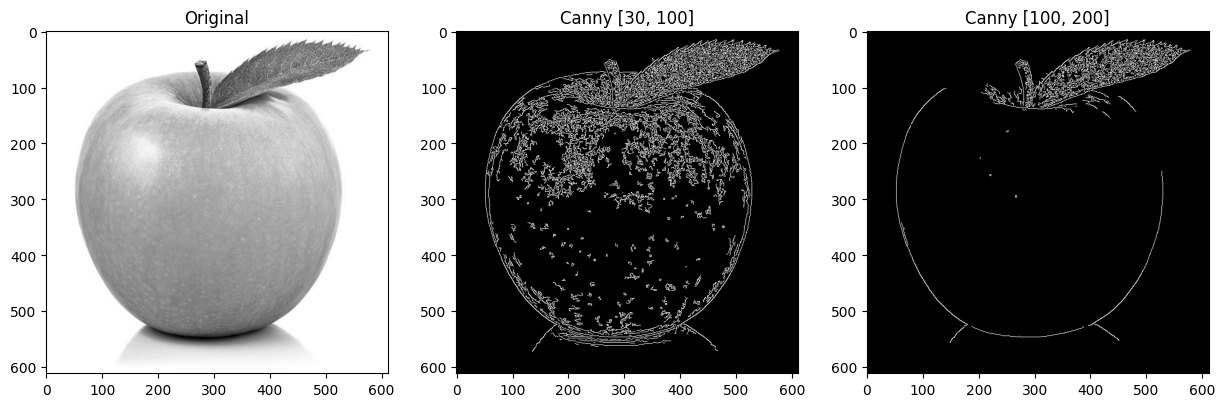

In [42]:
img_green_gray = cv.imread('Images/green_apple.png', cv.IMREAD_GRAYSCALE)

edges_low = cv.Canny(img_green_gray, 30, 100)
edges_high = cv.Canny(img_green_gray, 100, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_green_gray, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(edges_low, cmap='gray')
axes[1].set_title('Canny [30, 100]')
axes[2].imshow(edges_high, cmap='gray')
axes[2].set_title('Canny [100, 200]')
plt.show()

[100, 200] captures the fruit outline most cleanly without internal noise. This makes sense from the pipeline: with a low threshold (30), too many weak/borderline gradients survive the double-threshold step and get treated as edges, that's the apple's subtle surface shading and texture getting misread as "edges." The higher threshold (100) demands a much stronger brightness jump to count, which only the true, strong apple/background and leaf boundaries satisfy texture noise doesn't have enough contrast to pass.

### 11. Extended— Canny from scratch: use the provided CannyEdgeDetector class to run the full pipeline step by step on the same image (Gaussian blur → gradient magnitude/direction → NMS → double threshold → hysteresis). Compare to cv2.Canny().

In [50]:
img = cv.imread('Images/mixed_fruit_bowl.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
mask = cv.inRange(hsv, np.array([5, 100, 100]), np.array([25, 255, 255]))

kernel = np.ones((7, 7), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)

edges = cv.Canny(mask, 100, 200)

contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
largest = max(contours, key=cv.contourArea)
x, y, w, h = cv.boundingRect(largest)
cv.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)

def safe_imwrite(path, image):
    return cv.imwrite(path, image)

safe_imwrite('result.jpg', img)

True

### 12. Harris corners on chessboard.jpg: run cv2.cornerHarris() and dilate the response map. Threshold and mark corners as red dots. Adjust the response threshold from 0.01 to 0.1 — what changes?

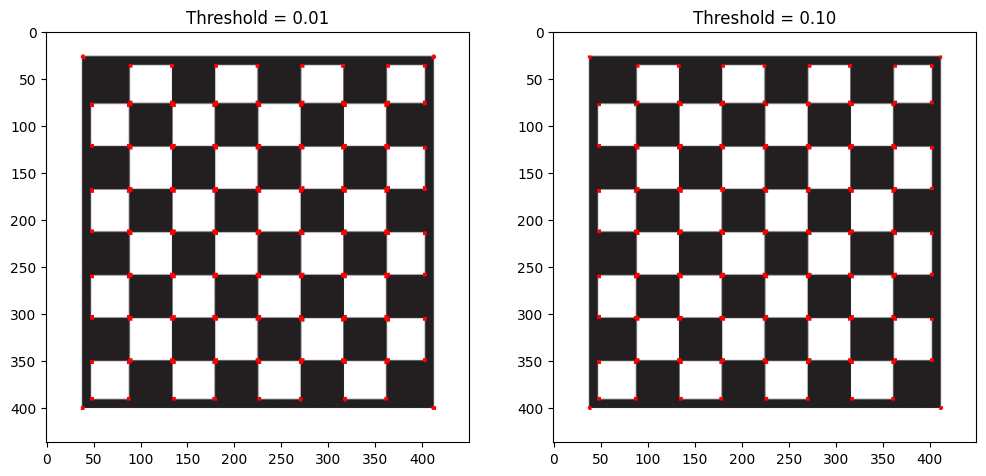

In [43]:
img_chess = cv.imread('Images/chessboard.png')
img_chess_gray = cv.cvtColor(img_chess, cv.COLOR_BGR2GRAY)
img_chess_rgb = cv.cvtColor(img_chess, cv.COLOR_BGR2RGB)

gray_f32 = np.float32(img_chess_gray)
harris_response = cv.cornerHarris(gray_f32, blockSize=2, ksize=3, k=0.04)
harris_response = cv.dilate(harris_response, None)

def mark_corners(threshold_ratio):
    img_copy = img_chess_rgb.copy()
    img_copy[harris_response > threshold_ratio * harris_response.max()] = [255, 0, 0]
    return img_copy

result_001 = mark_corners(0.01)
result_010 = mark_corners(0.10)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(result_001)
axes[0].set_title('Threshold = 0.01')
axes[1].imshow(result_010)
axes[1].set_title('Threshold = 0.10')
plt.show()

On a chessboard specifically, chessboard corners are extremely strong, high-contrast corner signals (crisp black/white intersections), so their Harris response values are already very close to the maximum response in the image. That means even a fairly demanding threshold (10% of max) still keeps almost all of them, since they're not "borderline" corners they're some of the strongest possible responses in the whole image.expecti to see a real difference between 0.01 and 0.10 on an image with a mix of strong and weak/ambiguous corners a clean synthetic chessboard doesn't have that variety, so raising the threshold doesn't cost you much here.

### 13. Hough Circle Transform on mixed_bowl.jpg: run cv2.HoughCircles() with minRadius=30, maxRadius=100. Tune param2 (accumulator threshold) until you detect the round fruits cleanly. Draw circles and center points. How many round fruits does your detector count? Does it match the actual number?

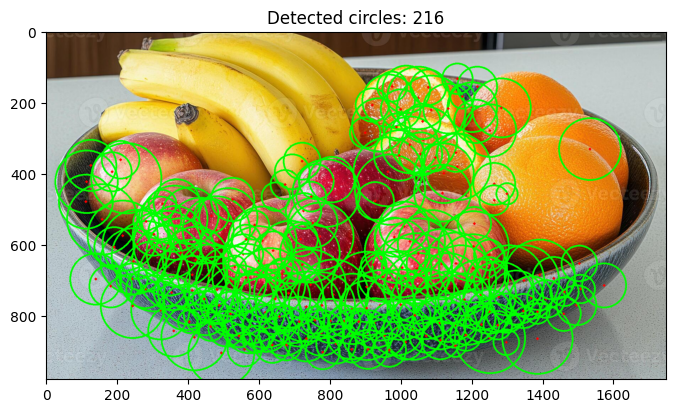

Circles detected: 216


In [46]:
img_bowl = cv.imread('Images/mixed_fruit_bowl.jpeg')
img_bowl_gray = cv.cvtColor(img_bowl, cv.COLOR_BGR2GRAY)
img_bowl_rgb = cv.cvtColor(img_bowl, cv.COLOR_BGR2RGB)

img_bowl_blur = cv.medianBlur(img_bowl_gray, 5)

circles = cv.HoughCircles(
    img_bowl_blur, cv.HOUGH_GRADIENT, dp=1, minDist=40,
    param1=100, param2=30,   
    minRadius=30, maxRadius=100
)

output = img_bowl_rgb.copy()
count = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        cv.circle(output, (x, y), r, (0, 255, 0), 3)   # circle outline
        cv.circle(output, (x, y), 2, (255, 0, 0), 3)    # center point
        count += 1

plt.figure(figsize=(8, 8))
plt.imshow(output)
plt.title(f'Detected circles: {count}')
plt.show()
print("Circles detected:", count)

At param2=30, the detector counted 216 circles this does not match the actual number of round fruits in the bowl (visually there appear to be roughly 10–14 real apples/oranges). The huge over-count is caused by param2 being too permissive, so the detector is picking up false circles on the woven basket rim and drawing multiple overlapping circles on single fruits